In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "3"

In [2]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from tqdm import tqdm, trange

from datasets import load_dataset
import pandas as pd
import functools
import sys
from pathlib import Path
from typing import Callable

# import circuitsvis as cv
import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import eindex
# from IPython.display import display
from jaxtyping import Float, Int
from torch import Tensor
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset, Dataset, DatasetDict
from transformers import AutoTokenizer
import os
import json
import matplotlib.pyplot as plt
import math
import seaborn as sns

/home/kokil/shaz/interp-toxicity/interp-toxicity2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("Available CUDA devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

Available CUDA devices: 1
Device 0: NVIDIA H100 80GB HBM3


In [4]:
tokenizer  = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    output_attentions=True      # optional
).to(device)
model.eval()
model.load_state_dict(torch.load('bert_classifier_vanilla/model_epoch_2_acc_0.9236.pt', map_location=device))

2025-06-04 11:48:40.076208: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-04 11:48:40.094605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749037720.113106 1324090 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749037720.118207 1324090 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749037720.132359 1324090 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

<All keys matched successfully>

## Patching

In [32]:
import math
import torch
import torch.nn as nn
from contextlib import contextmanager
from tqdm import trange

from transformers import BertModel, BertForSequenceClassification


# ----------------------------------------------------------------------------------------------------------------------
# 1) Helpers: Build a patched forward() that accepts *args, **kwargs
# ----------------------------------------------------------------------------------------------------------------------

def _make_patched_forward(self, head_to_zero: int):
    """
    Returns a function that can be bound to `BertSelfAttention.forward`
    in order to zero out `head_to_zero` right after the Softmax.
    """

    num_heads = self.num_attention_heads
    head_dim   = self.attention_head_size
    all_head_size = self.all_head_size

    def patched_forward(self, *args, **kwargs):
        """
        A drop-in replacement for BertSelfAttention.forward that zeroes one head.
        We expect this to be bound on `self = layer.attention.self`.
        """

        # --------------------------------------------------------------------------------
        # Step 1: Extract the actual arguments from *args and **kwargs
        # --------------------------------------------------------------------------------
        # In HuggingFace v4, the signature is roughly:
        #    def forward(
        #         self,
        #         hidden_states,
        #         attention_mask=None,
        #         head_mask=None,
        #         encoder_hidden_states=None,
        #         encoder_attention_mask=None,
        #         past_key_value=None,
        #         output_attentions=False,
        #         output_hidden_states=False,
        #         return_dict=True,
        #    ):
        #
        # We only care about hidden_states, attention_mask, head_mask, output_attentions for our patch.
        # Everything else we will ignore or pass through as-is when returning.

        # hidden_states is always the first positional argument:
        hidden_states = args[0]

        # The other parameters might come positionally or as keywords. We'll check both.
        attention_mask      = kwargs.get("attention_mask", None)
        head_mask           = kwargs.get("head_mask", None)
        output_attentions   = kwargs.get("output_attentions", False)

        # (We do NOT need encoder_hidden_states, etc., because BERT's BertSelfAttention
        #  does not use them in its own mask + softmax + matmul code path. Those are for cross-attention.)
        #
        # If you have a model where cross-attention is used inside the same class,
        # you would need to pull out encoder_hidden_states/encoder_attention_mask, etc.
        # But for plain BERT, we can ignore them.

        # --------------------------------------------------------------------------------
        # Step 2: Copy HuggingFace's logic up to (and after) softmax
        # --------------------------------------------------------------------------------
        mixed_query_layer = self.query(hidden_states)
        mixed_key_layer   = self.key(hidden_states)
        mixed_value_layer = self.value(hidden_states)
        # At this point: mixed_value_layer has shape (batch_size, seq_len, all_head_size).

        # A helper to reshape (batch, seq_len, all_head_size) → (batch, heads, seq_len, head_dim)
        def transpose_for_scores(x):
            new_shape = x.size()[:-1] + (num_heads, head_dim)
            x = x.view(*new_shape)
            return x.permute(0, 2, 1, 3)  # (batch, heads, seq_len, head_dim)

        query_layer = transpose_for_scores(mixed_query_layer)  # (B, H, S, head_dim)
        key_layer   = transpose_for_scores(mixed_key_layer)    # (B, H, S, head_dim)
        value_layer = transpose_for_scores(mixed_value_layer)  # (B, H, S, head_dim)

        # 1) Compute raw attention scores
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))  # (B, H, S, S)
        attention_scores = attention_scores / math.sqrt(head_dim)

        # 2) If there is an attention_mask, add it
        if attention_mask is not None:
            attention_scores = attention_scores + attention_mask

        # 3) Softmax → attention_probs, then dropout
        attention_probs = torch.nn.functional.softmax(attention_scores, dim=-1)
        attention_probs = torch.nn.functional.dropout(
            attention_probs,
            p=self.dropout.p if hasattr(self, "dropout") else 0.1,
            training=self.training
        )

        # --------------------------------------------------------------------------------
        # Step 3: Zero out exactly head_to_zero in attention_probs
        # --------------------------------------------------------------------------------
        # We clone first to avoid in-place side-effects in subsequent layers
        attention_probs = attention_probs.clone()
        attention_probs[:, head_to_zero, :, :] = 0.0

        # --------------------------------------------------------------------------------
        # Step 4: Apply head_mask if provided (same as HF code)
        # --------------------------------------------------------------------------------
        if head_mask is not None:
            attention_probs = attention_probs * head_mask

        # --------------------------------------------------------------------------------
        # Step 5: Compute context = attention_probs @ value_layer
        #          (B, H, S, S)    @ (B, H, S, head_dim) → (B, H, S, head_dim)
        # --------------------------------------------------------------------------------
        context_layer = torch.matmul(attention_probs, value_layer)

        # --------------------------------------------------------------------------------
        # Step 6: Permute / reshape back to (batch, seq_len, all_head_size)
        # --------------------------------------------------------------------------------
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()  # (B, S, H, head_dim)
        new_context_shape = context_layer.size()[:-2] + (all_head_size,)
        context_layer = context_layer.view(*new_context_shape)  # (B, S, hidden_size)

        # --------------------------------------------------------------------------------
        # Step 7: Build the return object exactly as BertSelfAttention does
        # --------------------------------------------------------------------------------
        outputs = (context_layer, attention_probs) if output_attentions else (context_layer,)
        
        # Finally return `outputs`. We do NOT return anything else (the calling code expects exactly
        # what HF returns: a tuple whose first element is context_layer, and second is attention_probs
        # if output_attentions=True).
        return outputs

    return patched_forward


@contextmanager
def zero_head(model: nn.Module, layer_idx: int, head_idx: int):
    """
    Temporarily patch layer `layer_idx`'s self-attention so that head `head_idx` is zeroed out
    right after the softmax. When we exit the context, we restore the original forward().

    Usage:
        with zero_head(model, layer_idx=0, head_idx=4):
            # Now layer0.head4 is disabled
            out = model(input_ids, attention_mask, labels=labels)
        # After the with-block, head 4 is restored.
    """
    # 1) Grab the BertSelfAttention submodule from the desired encoder layer
    layer_self_attn = model.bert.encoder.layer[layer_idx].attention.self

    # 2) Keep a reference to its original forward
    orig_forward = layer_self_attn.forward

    # 3) Create & bind our patched forward
    patched = _make_patched_forward(layer_self_attn, head_idx)
    layer_self_attn.forward = patched.__get__(layer_self_attn, type(layer_self_attn))

    try:
        yield
    finally:
        # 4) Restore the original forward method
        layer_self_attn.forward = orig_forward


# ----------------------------------------------------------------------------------------------------------------------
# 2) Main function: Compute Δ-loss for each (layer, head)
# ----------------------------------------------------------------------------------------------------------------------

def get_ablation_scores(
    classifier: nn.Module,
    input_ids:     torch.Tensor,
    attention_mask: torch.Tensor,
    labels:        torch.Tensor,
    criterion:     nn.Module,
):
    """
    For every (layer, head), temporarily zero out that head and compute:
        Δ-loss = Loss_with_head_zeroed − Loss_baseline.

    Returns:
      - scores:     torch.Tensor of shape (n_layers, n_heads) containing Δ-loss for each head
      - base_preds: torch.LongTensor of shape (batch_size,) with baseline predictions (no ablation)
      - predictions: dict mapping (layer, head) → torch.LongTensor of shape (batch_size,)
                     containing predictions when that head is zeroed.
    """

    n_layers = classifier.config.num_hidden_layers
    n_heads  = classifier.config.num_attention_heads
    device   = input_ids.device

    # 1) Compute the baseline (no head zeroed) loss & predictions
    classifier.eval()
    with torch.no_grad():
        # We call .forward(...) exactly as usual.
        base_out    = classifier(input_ids=input_ids,
                                 attention_mask=attention_mask,
                                 labels=labels,
                                 output_attentions=False)
        base_loss   = base_out.loss
        base_logits = base_out.logits
        base_preds  = torch.argmax(base_logits, dim=-1)

    # 2) Prepare containers
    scores      = torch.zeros(n_layers, n_heads, device=device)
    predictions = {}

    # 3) Loop over each layer & head
    for L in trange(n_layers, desc="Layers"):
        for H in range(n_heads):
            # Temporarily zero out head H in layer L
            with zero_head(classifier, layer_idx=L, head_idx=H):
                classifier.eval()
                with torch.no_grad():
                    out = classifier(input_ids=input_ids,
                                     attention_mask=attention_mask,
                                     labels=labels,
                                     output_attentions=False)
                    ablated_loss   = out.loss
                    ablated_logits = out.logits
                    ablated_preds  = torch.argmax(ablated_logits, dim=-1)

            # Δ-loss = ablated_loss − base_loss
            scores[L, H] = (ablated_loss - base_loss).detach()
            predictions[(L, H)] = ablated_preds.cpu()

    return scores.cpu(), base_preds.cpu(), predictions

In [33]:
criterion = nn.CrossEntropyLoss()

In [35]:
df = pd.read_csv('pwws_log.csv')

In [37]:
df[df.result_type == "Successful"].reset_index(drop=True).to_csv('pwws_log_successful.csv')

In [48]:
dataset = load_dataset("csv", data_files={"pwws_log.csv"})
# dataset = Dataset.from_pandas(df.groupby('toxic').sample(n=1000).reset_index(drop=True))
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})
# Tokenization function
def tokenize_data(example):
    return tokenizer(example["perturbed_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("ground_truth_output", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Generating train split: 1000 examples [00:00, 36201.48 examples/s]
Map: 100%|██████████| 1000/1000 [00:00<00:00, 1181.49 examples/s]


In [49]:
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels", "attention_mask"]}

# Create PyTorch DataLoaders
batch_size = 256
val_dataloader = DataLoader(JigsawDataset(dataset['train']), batch_size=batch_size, shuffle=False)

In [50]:
print('patching')
ablation_scores = torch.zeros(12,12, device=device)
base_preds = []
ablated_preds = {layer: {head : [] for head in range(model.config.num_attention_heads)} for layer in range(model.config.num_hidden_layers)}
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels, attention_mask = batch["input_ids"].to(device), batch["labels"].to(device), batch["attention_mask"].to(device)
    tmp_ablation_scores, base_pred, ablated_pred_list = get_ablation_scores(model, input_ids, attention_mask, labels, criterion)
    ablation_scores += tmp_ablation_scores.to(device)
    base_preds += base_pred.tolist()
    for layer in range(model.config.num_hidden_layers):
        for head in range(model.config.num_attention_heads):
            ablated_preds[layer][head] += ablated_pred_list[(layer, head)].tolist()
    # if i == 16:
    #     break

# ablation_scores /= len(val_dataloader)
# torch.save(ablation_scores, "bert_ablation_scores_jigsaw_perturbed.pth")

patching


100%|██████████| 4/4 [01:58<00:00, 29.71s/it]


## Testing

In [6]:
dataset = load_dataset("csv", data_files={"input_reduction_log.csv"})
# dataset = Dataset.from_pandas(df.groupby('toxic').sample(n=1000).reset_index(drop=True))
# dataset = load_dataset('csv', data_files={'test': 'toxigen_alice.csv'})
# Tokenization function
def tokenize_data(example):
    return tokenizer(example["perturbed_text"], padding="max_length", truncation=True, max_length=128, return_tensors="pt")

# Apply tokenization
dataset = dataset.map(tokenize_data, batched=True)
dataset = dataset.rename_column("ground_truth_output", "labels")  # Rename for consistency
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Generating train split: 2500 examples [00:00, 46016.61 examples/s]
Map: 100%|██████████| 2500/2500 [00:00<00:00, 9569.89 examples/s] 


In [7]:
class JigsawDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return {key: self.dataset[idx][key] for key in ["input_ids", "labels", "attention_mask"]}

# Create PyTorch DataLoaders
batch_size = 64
val_dataloader = DataLoader(JigsawDataset(dataset['train']), batch_size=batch_size, shuffle=False)

In [11]:
print('patching')
ablation_scores = torch.zeros(12,12, device=device)
base_preds = []
ablated_preds = {layer: {head : [] for head in range(model.config.num_attention_heads)} for layer in range(model.config.num_hidden_layers)}
for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
    input_ids, labels, attention_mask = batch["input_ids"].to(device), batch["labels"].to(device), batch["attention_mask"].to(device)
    tmp_ablation_scores, base_pred, ablated_pred_list = get_ablation_scores(model, input_ids, attention_mask, labels, criterion)
    ablation_scores += tmp_ablation_scores.to(device)
    base_preds += base_pred.tolist()
    for layer in range(model.config.num_hidden_layers):
        for head in range(model.config.num_attention_heads):
            ablated_preds[layer][head] += ablated_pred_list[(layer, head)].tolist()
    if i == 16:
        break

# ablation_scores /= len(val_dataloader)
# torch.save(ablation_scores, "bert_ablation_scores_jigsaw_perturbed.pth")

patching


 15%|█▌        | 6/40 [14:09<1:20:11, 141.52s/it]


KeyboardInterrupt: 

## Analysis

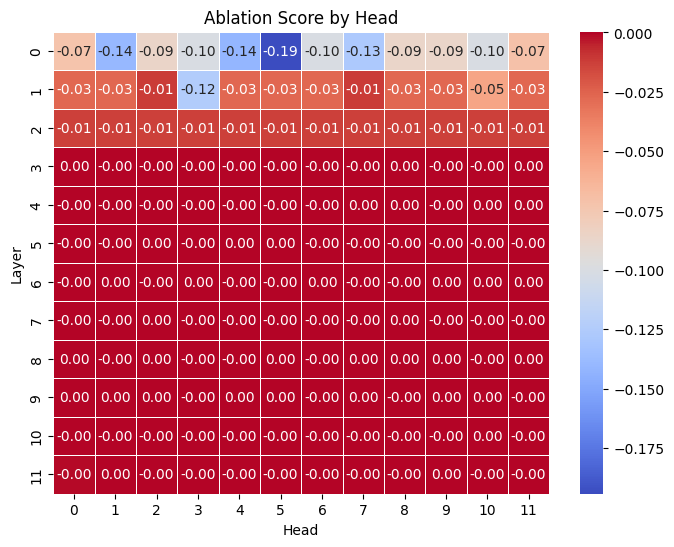

In [51]:
tensor_np = ablation_scores.cpu().detach().numpy()
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap(tensor_np, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Ablation Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# Show the plot
plt.show()

In [52]:
df = pd.read_csv('pwws_log.csv')

In [53]:
acc_scores = np.zeros((12,12))
for i in range(12):
    for j in range(12):
        acc_scores[i][j] = np.mean(df.ground_truth_output == np.array(ablated_preds[i][j]))

In [54]:
base_acc = np.mean(df.ground_truth_output == np.array(base_preds))
base_acc

0.908

In [55]:
len(base_preds)

1000

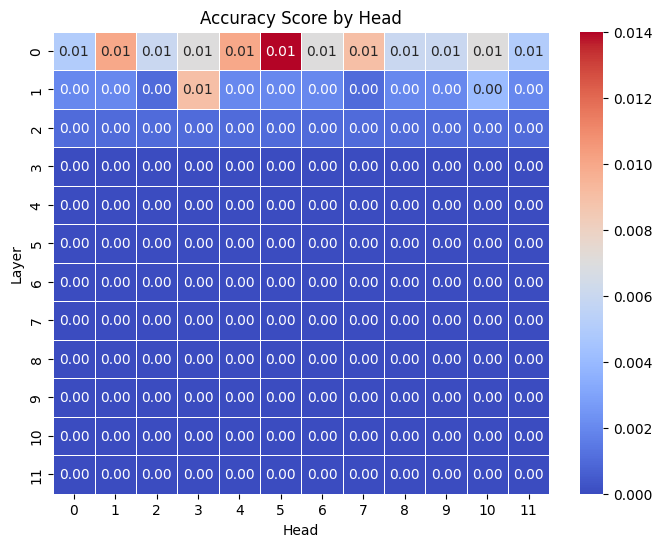

In [56]:
# Plot the heatmap
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.heatmap((acc_scores - base_acc), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add labels
plt.title("Accuracy Score by Head")
plt.xlabel("Head")
plt.ylabel("Layer")

# plt.savefig(f'{attack_name}/bert_jigsaw_perturbed_accuracy_scores_by_head.png')
# Show the plot
plt.show()

In [57]:
max_value = np.max(acc_scores)
max_indices = np.unravel_index(np.argmax(acc_scores), acc_scores.shape)
print("Maximum value:", max_value)
print("Indices of maximum value (layer, head):", max_indices)

Maximum value: 0.922
Indices of maximum value (layer, head): (0, 5)
